In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Load the image
image = cv2.imread("images/blind_guide_2.jpg")

# # Convert from BGR (OpenCV default) to RGB (for proper display)
# image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# # Display the image
# plt.imshow(image_rgb)
# plt.axis("off")  # Hide axes
# plt.show()

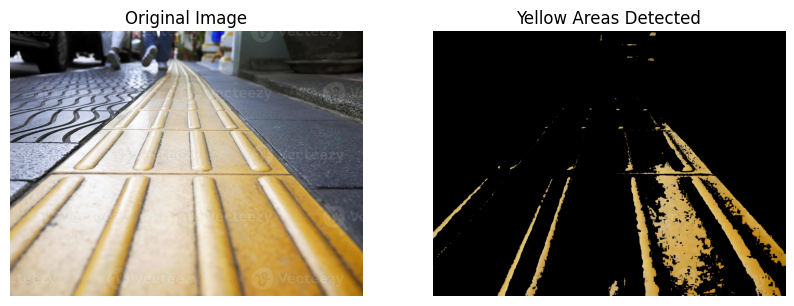

In [21]:
# Convert from BGR (OpenCV default) to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define the range of yellow in HSV
lower_yellow = np.array([20, 100, 100])  # Lower bound of yellow
upper_yellow = np.array([40, 255, 255])  # Upper bound of yellow

# Create a mask to filter out yellow
mask = cv2.inRange(hsv, lower_yellow, upper_yellow)

# Apply the mask to get the yellow parts of the image
yellow_detected = cv2.bitwise_and(image, image, mask=mask)

# Convert to RGB for display
yellow_detected_rgb = cv2.cvtColor(yellow_detected, cv2.COLOR_BGR2RGB)

# Show the original image and the yellow-detected image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(yellow_detected_rgb)
plt.title("Yellow Areas Detected")
plt.axis("off")

plt.show()

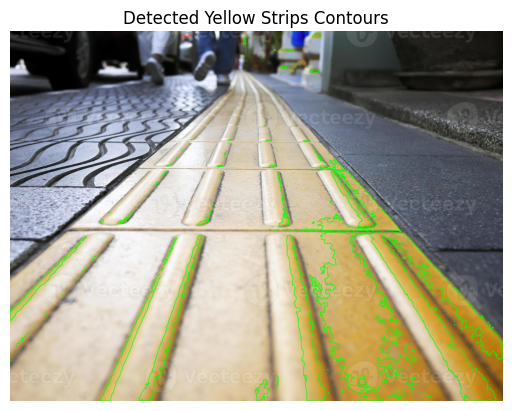

In [22]:
# Find contours in the yellow mask
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on the original image for visualization
image_with_contours = image.copy()
cv2.drawContours(image_with_contours, contours, -1, (0, 255, 0), 2)  # Green contours

# Convert to RGB for displaying in Jupyter Notebook
plt.imshow(cv2.cvtColor(image_with_contours, cv2.COLOR_BGR2RGB))
plt.title("Detected Yellow Strips Contours")
plt.axis("off")
plt.show()

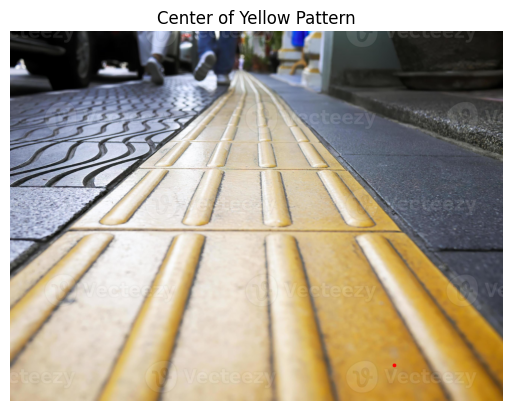

Center of Yellow Pattern: (x=2035, y=1771)


In [23]:
if contours:
    # Combine all contours into one
    all_points = np.vstack(contours)  # Stack all contour points together

    # Compute the centroid using image moments
    M = cv2.moments(all_points)
    
    if M["m00"] != 0:  # Avoid division by zero
        center_x = int(M["m10"] / M["m00"])
        center_y = int(M["m01"] / M["m00"])

        # Draw the center point on the image
        result_image = image.copy()
        cv2.circle(result_image, (center_x, center_y), 10, (0, 0, 255), -1)  # Red dot

        # Display the result
        plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
        plt.title("Center of Yellow Pattern")
        plt.axis("off")
        plt.show()

        # Print the coordinates of the detected center
        print(f"Center of Yellow Pattern: (x={center_x}, y={center_y})")
    else:
        print("No valid yellow area found!")
else:
    print("No yellow pattern detected!")